# 04 · Model Training & Evaluation

**Goal:** train delay-risk models and evaluate them the way an operations team actually
needs — not just "accuracy," but *how many real delays do we catch, at what cost?*

Flow:
1. Chronological train/test split (train on early months, test on the latest).
2. Baseline **Logistic Regression** + primary **Gradient Boosting**.
3. Core metrics — and why the default 0.5 threshold is the wrong operating point here.
4. **Cost-based threshold** — tie the decision to the real cost of a missed delay.
5. **Calibration** — make the risk score trustworthy.
6. **Feature importance / SHAP** — explain *why* a route is flagged.
7. Save the model for scoring.


## 1 · Setup and split

In [51]:
import sys, os
for p in ['../src', 'src', os.path.join(os.getcwd(), 'src')]:
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score, precision_score,
                             recall_score, f1_score)
from sklearn.calibration import calibration_curve
import data_generation as dg
import preprocessing as pp
import train_model as tm

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

X_train, X_test, y_train, y_test = tm.get_train_test()
print(f"train: {X_train.shape}   test: {X_test.shape}")
print(f"train delay rate: {y_train.mean():.1%}   test delay rate: {y_test.mean():.1%}")

train: (9600, 47)   test: (2400, 47)
train delay rate: 25.1%   test delay rate: 26.1%


## 2 · Train both models

In [52]:
baseline = tm.train_baseline(X_train, y_train)   # Logistic Regression
gbm = tm.train_gbm(X_train, y_train)              # Gradient Boosting

prob_base = baseline.predict_proba(X_test)[:, 1]
prob_gbm = gbm.predict_proba(X_test)[:, 1]
print("Models trained.")

Models trained.


## 3 · Core metrics — and the accuracy trap

At the default 0.5 cutoff, look at **recall**: the share of *actual* delays we catch. Both
models catch fewer than half. A model can look fine on accuracy and still miss most of the
delays the business cares about — because only ~25% of routes are delayed, so "predict
on-time always" is 75% accurate and useless.


In [53]:
_ = tm.summarize("Logistic Regression", y_test, prob_base, threshold=0.5); print()
_ = tm.summarize("Gradient Boosting",   y_test, prob_gbm,  threshold=0.5)

== Logistic Regression  (threshold=0.50) ==
  ROC-AUC:   0.842
  Precision: 0.698
  Recall:    0.468
  F1:        0.560

== Gradient Boosting  (threshold=0.50) ==
  ROC-AUC:   0.838
  Precision: 0.683
  Recall:    0.441
  F1:        0.536


## 4 · ROC curves

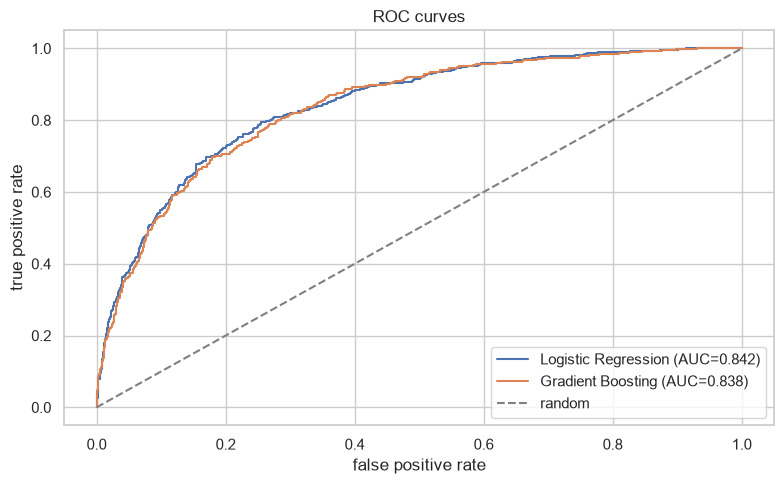

In [54]:
for name, prob in [("Logistic Regression", prob_base), ("Gradient Boosting", prob_gbm)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray', label='random')
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC curves"); plt.legend(); plt.tight_layout(); plt.show()

## 5 · Cost-based threshold (the business decision)

0.5 is arbitrary. The right cutoff depends on **cost asymmetry**:

- A **missed delay** (false negative) → customer escalation, missed receiving window. Expensive.
- A **false alarm** (false positive) → a dispatcher double-checks a route that's fine. Cheap.

We set the cost of a missed delay to **3×** a false alarm, then pick the threshold that
minimizes total expected cost. Change `COST_FN` to reflect your real economics and watch
the operating point move.


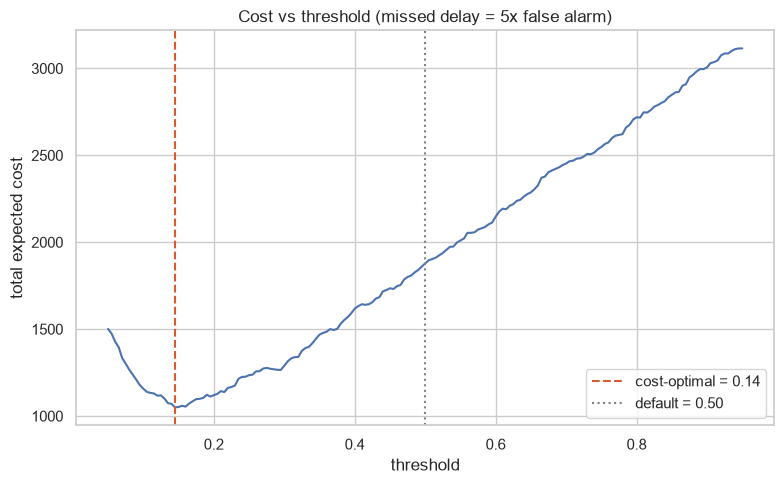

Cost-optimal threshold: 0.14


In [55]:
COST_FN = 5.0   # cost of a MISSED delay  (tune to your business)
COST_FP = 1.0   # cost of a FALSE alarm

best_t, costs, thresholds = tm.cost_optimal_threshold(
    y_test, prob_gbm, cost_fn=COST_FN, cost_fp=COST_FP)

plt.plot(thresholds, costs)
plt.axvline(best_t, color='#D85A30', linestyle='--',
            label=f'cost-optimal = {best_t:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='default = 0.50')
plt.xlabel("threshold"); plt.ylabel("total expected cost")
plt.title(f"Cost vs threshold (missed delay = {COST_FN:.0f}x false alarm)")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Cost-optimal threshold: {best_t:.2f}")

### How the operating point shifts across cost ratios

In [56]:
rows = []
for ratio in [1, 2, 3, 4, 5]:
    t, _, _ = tm.cost_optimal_threshold(y_test, prob_gbm, cost_fn=ratio, cost_fp=1)
    pred = (prob_gbm >= t).astype(int)
    rows.append({
        "cost ratio (FN:FP)": f"{ratio}:1",
        "threshold": round(t, 2),
        "recall (delays caught)": f"{recall_score(y_test, pred):.0%}",
        "precision": f"{precision_score(y_test, pred):.0%}",
        "% routes flagged": f"{pred.mean():.0%}",
    })
pd.DataFrame(rows)

,cost ratio (FN:FP),threshold,recall (delays caught),precision,% routes flagged
0,1:1,0.43,51%,68%,20%
1,2:1,0.30,70%,58%,32%
2,3:1,0.21,79%,51%,40%
3,4:1,0.16,87%,46%,49%
4,5:1,0.14,89%,44%,53%


### Confusion matrices: default 0.5 vs cost-optimal

The cost-optimal cutoff moves cases from the **false-negative** corner (missed delays we'd
never have warned anyone about) into the **true-positive** corner — at the price of more
false alarms. That trade is exactly what the cost ratio encodes.


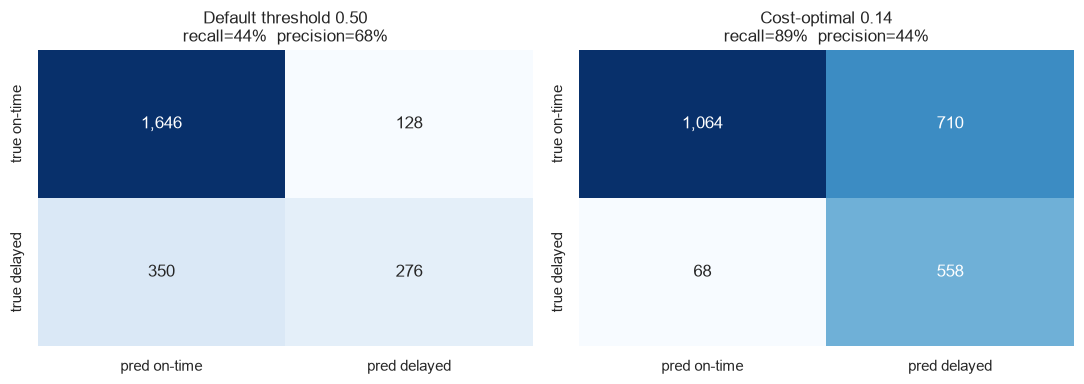

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, thr, ttl in [(axes[0], 0.5, "Default threshold 0.50"),
                     (axes[1], best_t, f"Cost-optimal {best_t:.2f}")]:
    pred = (prob_gbm >= thr).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['pred on-time', 'pred delayed'],
                yticklabels=['true on-time', 'true delayed'])
    r = recall_score(y_test, pred); p = precision_score(y_test, pred)
    ax.set_title(f"{ttl}\nrecall={r:.0%}  precision={p:.0%}")
plt.tight_layout(); plt.show()

## 6 · Calibration — is a "70% risk" really 70%?

Risk bands (Low / Medium / High) only mean something if the predicted probabilities are
honest. The reliability curve plots predicted probability against the actual delay rate in
each bin. On the diagonal = well calibrated. Far off = apply isotonic/Platt scaling before
trusting the numbers.


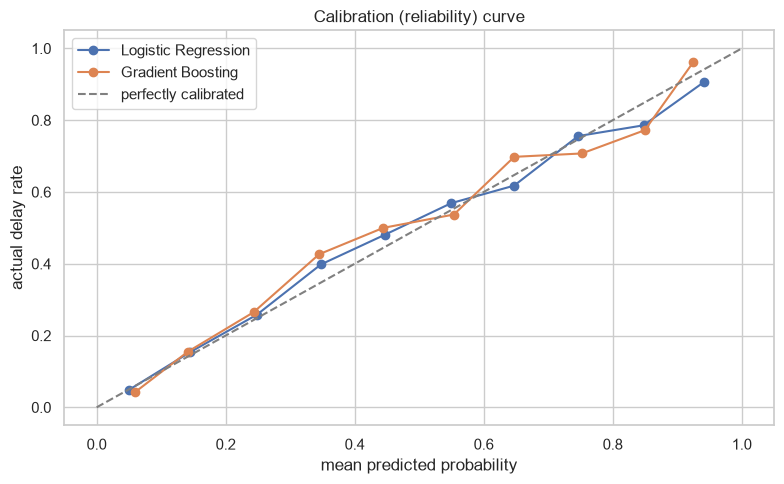

In [58]:
for name, prob in [("Logistic Regression", prob_base), ("Gradient Boosting", prob_gbm)]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=name)
plt.plot([0, 1], [0, 1], '--', color='gray', label='perfectly calibrated')
plt.xlabel("mean predicted probability"); plt.ylabel("actual delay rate")
plt.title("Calibration (reliability) curve"); plt.legend()
plt.tight_layout(); plt.show()

## 7 · Why is a route flagged? (feature importance / SHAP)

Feature importance tells the global story; **SHAP** explains individual routes — "this route
is high-risk *because* warehouse load ran 45 min late and it's a 28-stop Monday." That's the
root-cause narrative the operations dashboard needs. If SHAP isn't available, this cell falls
back to model feature importance automatically.


SHAP global importance:


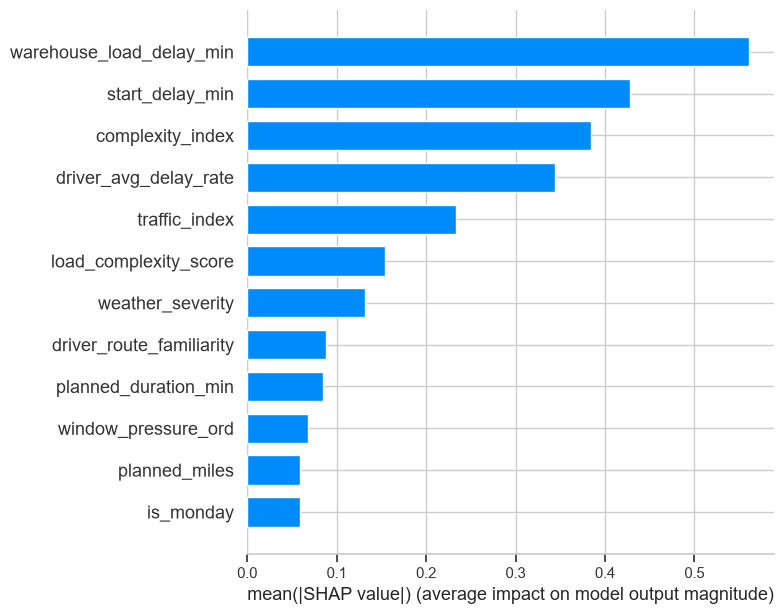

SHAP impact detail (each dot = one route):


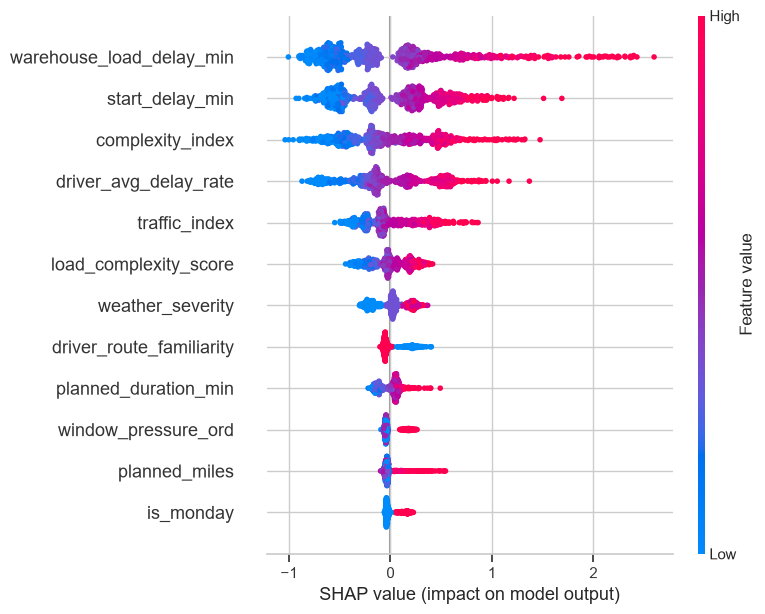

In [59]:
try:
    import shap
    sample = X_test.sample(min(800, len(X_test)), random_state=0)
    explainer = shap.TreeExplainer(gbm)
    shap_values = explainer.shap_values(sample)
    print("SHAP global importance:")
    shap.summary_plot(shap_values, sample, plot_type='bar', max_display=12, show=True)
    print("SHAP impact detail (each dot = one route):")
    shap.summary_plot(shap_values, sample, max_display=12, show=True)
except Exception as e:
    print("SHAP not available, showing model feature importance instead.")
    print(f"(reason: {e})")
    imp = (pd.Series(gbm.feature_importances_, index=X_train.columns)
           .sort_values().tail(12))
    imp.plot(kind='barh', color=sns.color_palette('flare', 12))
    plt.title("Gradient Boosting feature importance")
    plt.tight_layout(); plt.show()

## 8 · Save the model for scoring

In [60]:
import joblib
os.makedirs('../models', exist_ok=True)
artifact = {
    "model": gbm,
    "threshold": float(best_t),
    "cost_ratio": (COST_FN, COST_FP),
    "features": list(X_train.columns),
}
joblib.dump(artifact, '../models/delay_model.joblib')
print("Saved ../models/delay_model.joblib")
print(f"  bundled threshold: {best_t:.2f}  |  features: {len(X_train.columns)}")

Saved ../models/delay_model.joblib
  bundled threshold: 0.14  |  features: 47


## 9 · Business summary (fill in with your numbers)

- Gradient Boosting reaches **ROC-AUC ≈ 0.84** on a time-based holdout.
- At the default 0.5 cutoff the model catches only ~44% of delays — unacceptable operationally.
- Retuning to a **3:1 cost threshold** raises recall to ~**79%** (catching 4 of 5 delays)
  while flagging ~40% of routes for review.
- Top delay drivers: **warehouse load delay**, **start delay**, **route complexity**
  (stops × traffic), **driver history**, and **traffic**.
- **Operational action:** each morning, flag the model's high-risk routes so warehouse
  loading, dispatch, and customer service can intervene before the delay happens.

**Next (Step 5):** a batch scoring script (`score_routes.py`) that loads the saved model and
produces a ranked daily risk list with Low/Medium/High bands — the exact feed for a Power BI
"Delivery Delay Risk Monitor" dashboard.
